### **Praktikum Mandiri 12 | ML Senin Pagi**

Nama : Rika Rahma

NIM : 0110222134

Rombel : TI08 - 2022

1. Import Library

In [49]:
# Import Library
# Pada tahap ini, dilakukan impor pustaka Python yang diperlukan untuk analisis data, reduksi dimensi dengan PCA,
# serta pelatihan dan evaluasi model klasifikasi menggunakan algoritma SVM (Support Vector Machine).
# Library utama mencakup: NumPy dan Pandas untuk manipulasi data, Scikit-learn untuk PCA, SVM, dan metrik evaluasi,
# serta Matplotlib untuk visualisasi grafis 3D.

import numpy as np
import pandas as pd

# Import dataset dan preprocessing dari Scikit-learn
from sklearn.datasets import load_breast_cancer  # Dataset Breast Cancer Wisconsin (569 sampel, 30 fitur, target binary)
from sklearn.model_selection import train_test_split  # Pembagian data train-test
from sklearn.preprocessing import StandardScaler  # Standardisasi fitur untuk PCA
from sklearn.decomposition import PCA  # Principal Component Analysis untuk reduksi dimensi
from sklearn.svm import SVC  # Support Vector Classifier dengan kernel RBF
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluasi model

# Import visualisasi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Untuk plot 3D
import seaborn as sns  # Untuk heatmap dan plot tambahan (opsional)

# Pengaturan tampilan
plt.style.use('seaborn-v0_8')  # Gaya plot yang lebih menarik
sns.set_palette("husl")  # Palet warna untuk scatter plot
# Agar plot rapi
plt.rcParams['figure.figsize'] = (8, 6)

2. Load Dataset

In [50]:
# Load Dataset
# Dataset Breast Cancer Wisconsin dimuat dari Scikit-learn, yang berisi 569 sampel dengan 30 fitur numerik
# (misalnya: mean radius, texture, perimeter, area, smoothness, dll.) dan target biner:
# - 0: Malignant (ganas, 212 sampel)
# - 1: Benign (jinak, 357 sampel)
# Data dikonversi ke DataFrame Pandas untuk kemudahan eksplorasi.

# Load dataset
cancer = load_breast_cancer()

# Konversi ke DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # Tambahkan kolom target (0: malignant, 1: benign)

# Menampilkan 5 baris pertama
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [51]:
# Tampilkan info dasar
print("Info Dataset:")
df.info()

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness e

In [52]:
print("\nDeskripsi Statistik:")
df.describe()


Deskripsi Statistik:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [53]:
print("\nDistribusi Target:")
df.value_counts()


Distribusi Target:


,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,
28.110,18.47,188.50,2499.0,0.11420,0.15160,0.32010,0.159500,0.1648,0.05525,2.8730,1.4760,21.980,525.600,0.013450,0.027720,0.06389,0.014070,0.04783,0.004476,28.110,18.47,188.50,2499.0,0.11420,0.15160,0.32010,0.15950,0.1648,0.05525,0,1
6.981,13.43,43.79,143.5,0.11700,0.07568,0.00000,0.000000,0.1930,0.07818,0.2241,1.5080,1.553,9.833,0.010190,0.010840,0.00000,0.000000,0.02659,0.004100,7.930,19.54,50.41,185.2,0.15840,0.12020,0.00000,0.00000,0.2932,0.09382,1,1
7.691,25.44,48.34,170.4,0.08668,0.11990,0.09252,0.013640,0.2037,0.07751,0.2196,1.4790,1.445,11.730,0.015470,0.064570,0.09252,0.013640,0.02105,0.007551,8.678,31.89,54.49,223.6,0.15960,0.30640,0.33930,0.05000,0.2790,0.10660,1,1
7.729,25.49,47.98,178.8,0.08098,0.04878,0.00000,0.000000,0.1870,0.07285,0.3777,1.4620,2.492,19.140,0.012660,0.009692,0.00000,0.000000,0.02882,0.006872,9.077,30.92,57.17,248.0,0.12560,0.08340,0.00000,0.00000,0.3058,0.09938,1,1
7.760,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.000000,0.1587,0.05884,0.3857,1.4280,2.548,19.150,0.007189,0.004660,0.00000,0.000000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.00000,0.00000,0.2871,0.07039,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8.878,15.49,56.74,241.0,0.08293,0.07698,0.04721,0.023810,0.1930,0.06621,0.5381,1.2000,4.277,30.180,0.010930,0.028990,0.03214,0.015060,0.02837,0.004174,9.981,17.70,65.27,302.0,0.10150,0.12480,0.09441,0.04762,0.2434,0.07431,1,1
8.734,16.84,55.27,234.3,0.10390,0.07428,0.00000,0.000000,0.1985,0.07098,0.5169,2.0790,3.167,28.850,0.015820,0.019660,0.00000,0.000000,0.01865,0.006736,10.170,22.80,64.01,317.0,0.14600,0.13100,0.00000,0.00000,0.2445,0.08865,1,1
8.726,15.83,55.84,230.9,0.11500,0.08201,0.04132,0.019240,0.1649,0.07633,0.1665,0.5864,1.354,8.966,0.008261,0.022130,0.03259,0.010400,0.01708,0.003806,9.628,19.62,64.48,284.4,0.17240,0.23640,0.24560,0.10500,0.2926,0.10170,1,1


3. Exploratory Data Analysis (EDA)

In [54]:
# Exploratory Data Analysis (EDA)
# Tahap ini melakukan pemeriksaan awal data untuk memahami struktur, mendeteksi missing values, duplikat,
# dan distribusi target. Dataset Breast Cancer bersih (tidak ada null atau duplikat), dengan distribusi
# yang sedikit tidak seimbang (benign lebih banyak). Visualisasi heatmap korelasi menunjukkan adanya
# korelasi tinggi antar fitur (misalnya radius dengan perimeter), yang menjadi alasan utama penggunaan PCA
# untuk reduksi dimensi dan menghilangkan redundansi.

# Cek missing values
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [55]:
# Cek duplicat
df.duplicated().sum()

np.int64(0)

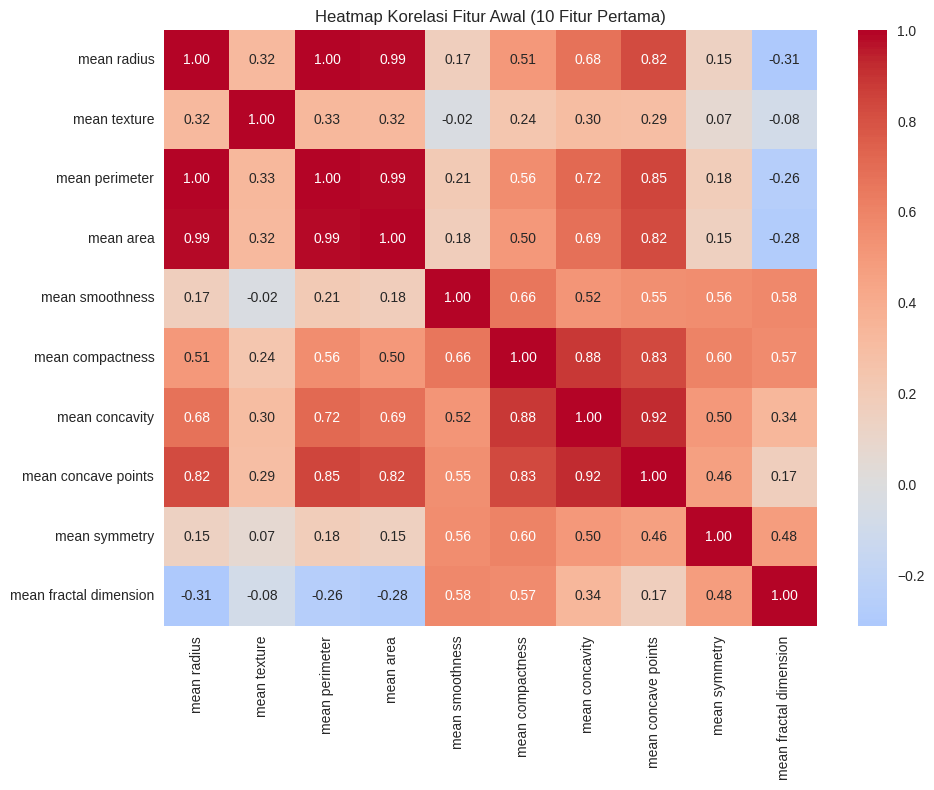

In [56]:
# Heatmap korelasi untuk melihat redundansi fitur (fokus pada 10 fitur utama untuk simplicity)
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :10].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heatmap Korelasi Fitur Awal (10 Fitur Pertama)')
plt.tight_layout()
plt.show()

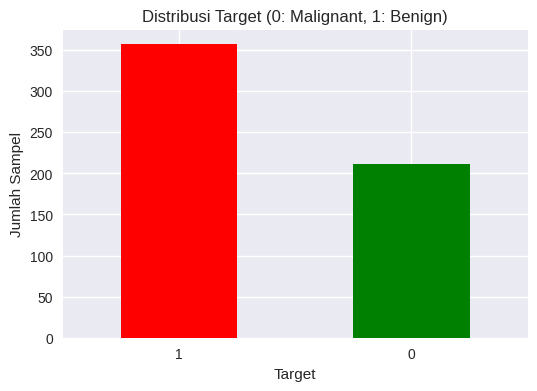

In [57]:
# Distribusi target
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Distribusi Target (0: Malignant, 1: Benign)')
plt.xlabel('Target')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.show()

4. Pemisahan Fitur dan Label

In [58]:
# Preprocessing Data
# Data dipisahkan menjadi fitur (X: 30 fitur numerik) dan target (y: biner).
# Dilakukan train-test split dengan rasio 80:20 dan stratify untuk menjaga proporsi kelas.
# Standardisasi menggunakan StandardScaler untuk menormalkan skala fitur (mean=0, std=1),
# karena PCA sensitif terhadap variansi fitur yang berbeda-beda.

# Pisah fitur dan target
X = df.drop('target', axis=1).values  # Fitur: 30 kolom numerik
y = df['target'].values  # Target: biner

In [59]:
# Train-test split (80% train, 20% test, random_state=42 untuk reproduktifitas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran Train: {X_train.shape[0]} sampel, {X_train.shape[1]} fitur")
print(f"Ukuran Test: {X_test.shape[0]} sampel")

Ukuran Train: 455 sampel, 30 fitur
Ukuran Test: 114 sampel


In [60]:
# Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit + transform pada train
X_test_scaled = scaler.transform(X_test)  # Hanya transform pada test (hindari data leakage)

print("Standardisasi selesai. Mean train (harus ~0):", np.mean(X_train_scaled[:, 0]))
print("Std train:", np.std(X_train_scaled[:, 0]))

Standardisasi selesai. Mean train (harus ~0): -4.337433952909183e-15
Std train: 1.0


5. Baseline Model SVM Tanpa PCA

In [61]:
# Baseline Model SVM Tanpa PCA
# Model baseline menggunakan SVM dengan kernel RBF (gamma='scale') dilatih pada data standar tanpa reduksi dimensi.
# Evaluasi mencakup akurasi, classification report (precision, recall, F1-score), dan confusion matrix.

# Inisialisasi dan latih SVM
svm_baseline = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_baseline.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [62]:
# Prediksi pada test
y_pred_baseline = svm_baseline.predict(X_test_scaled)

In [63]:
# Evaluasi
acc_baseline = accuracy_score(y_test, y_pred_baseline) * 100
print(f"Akurasi SVM Tanpa PCA: {acc_baseline:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Malignant', 'Benign']))

Akurasi SVM Tanpa PCA: 98.25%

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



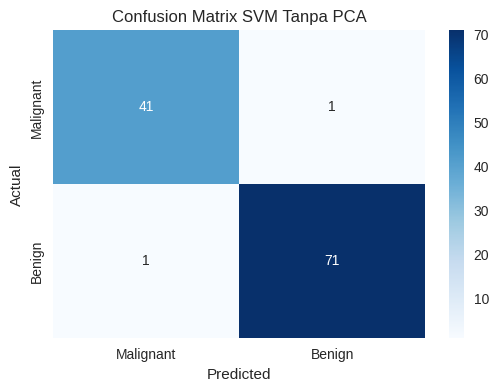

In [64]:
# Confusion Matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix SVM Tanpa PCA')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


--- ANALISIS PCA: MENENTUKAN JUMLAH KOMPONEN OPTIMAL ---


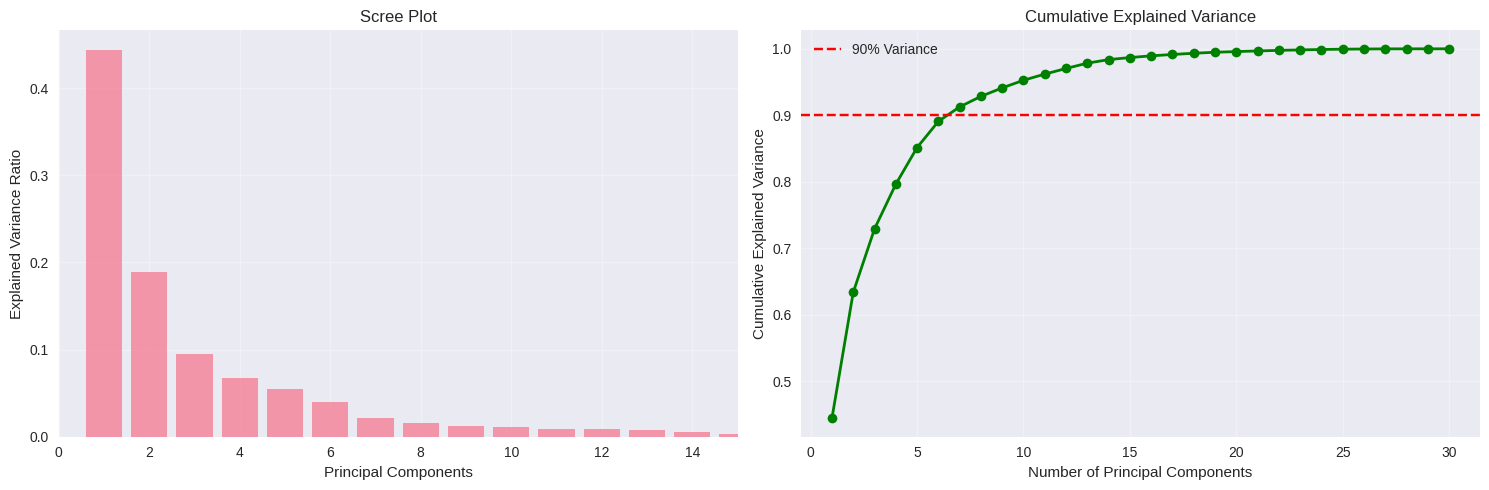

Jumlah komponen untuk menjelaskan 90% varians: 7 komponen
Total varian yang dijelaskan oleh 3 komponen: 72.90%


In [76]:
# Analisis PCA - Menentukan Jumlah Komponen Optimal
print("\n--- ANALISIS PCA: MENENTUKAN JUMLAH KOMPONEN OPTIMAL ---")

# Fit PCA dengan semua komponen (n_components=None)
pca_full = PCA(n_components=None)
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Visualisasi Scree Plot dan Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Scree Plot (Explained Variance)
axes[0].bar(range(1, 31), explained_variance, alpha=0.7)
axes[0].set_xlabel('Principal Components')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xlim(0, 15)
axes[0].grid(True, alpha=0.3)

# 2. Cumulative Variance Plot
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='green', linewidth=2)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Cari n_components yang menjelaskan 90% varians
n_optimal_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Jumlah komponen untuk menjelaskan 90% varians: {n_optimal_90} komponen")
print(f"Total varian yang dijelaskan oleh 3 komponen: {cumulative_variance[2]*100:.2f}%")

6. Implementasi PCA

In [66]:
# Implementasi PCA
# PCA diterapkan dengan n_components=3 untuk reduksi dari 30 fitur ke 3 principal components,
# Explained variance ratio menunjukkan proporsi variansi yang dijelaskan oleh setiap PCA

# Terapkan PCA
pca = PCA(n_components=3, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)  # Fit + transform train
X_test_pca = pca.transform(X_test_scaled)  # Transform test

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
print("Explained Variance Ratio per PC:", explained_var)
print(f"Total Varian Dijelaskan (3 PC): {sum(explained_var)*100:.2f}%")

Explained Variance Ratio per PC: [0.44413492 0.18944618 0.09543356]
Total Varian Dijelaskan (3 PC): 72.90%


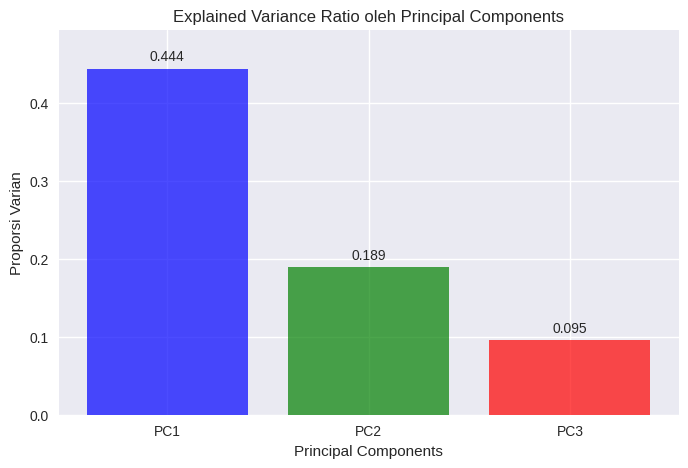

In [67]:
# Bar chart visualisasi explained variance
plt.figure(figsize=(8, 5))
plt.bar(['PC1', 'PC2', 'PC3'], explained_var, color=['blue', 'green', 'red'], alpha=0.7)
plt.title('Explained Variance Ratio oleh Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Proporsi Varian')
plt.ylim(0, max(explained_var) + 0.05)
for i, v in enumerate(explained_var):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.show()

In [68]:
# Cek korelasi antar PC (harus mendekati 0, orthogonal)
df_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2', 'PC3'])
print("\nKorelasi Antar PC:")
print(df_pca.corr())


Korelasi Antar PC:
              PC1           PC2           PC3
PC1  1.000000e+00  1.285351e-16 -1.169395e-17
PC2  1.285351e-16  1.000000e+00  8.323433e-17
PC3 -1.169395e-17  8.323433e-17  1.000000e+00


7. SVM dengan PCA

In [69]:
# SVM dengan PCA
# Model SVM dilatih ulang pada data PCA (3 fitur). Evaluasi serupa dengan baseline.
# Diharapkan akurasi tetap tinggi (~95%) meski dimensi turun drastis, membuktikan PCA efektif
# untuk mengurangi kompleksitas tanpa kehilangan performa signifikan.

# Latih SVM pada data PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi
y_pred_pca = svm_pca.predict(X_test_pca)

# Evaluasi
acc_pca = accuracy_score(y_test, y_pred_pca) * 100
print(f"Akurasi SVM dengan PCA: {acc_pca:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca, target_names=['Malignant', 'Benign']))

Akurasi SVM dengan PCA: 94.74%

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



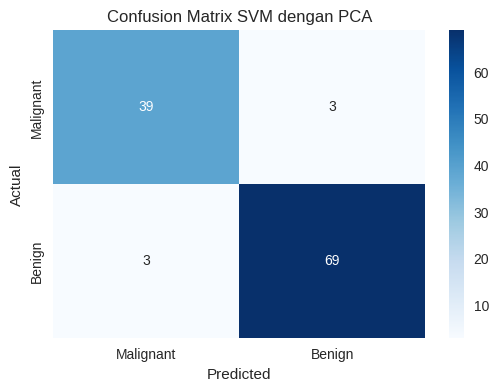

In [70]:
# Confusion Matrix
cm_pca = confusion_matrix(y_test, y_pred_pca)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix SVM dengan PCA')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

8. Visualisasi 3D Scatter Plot

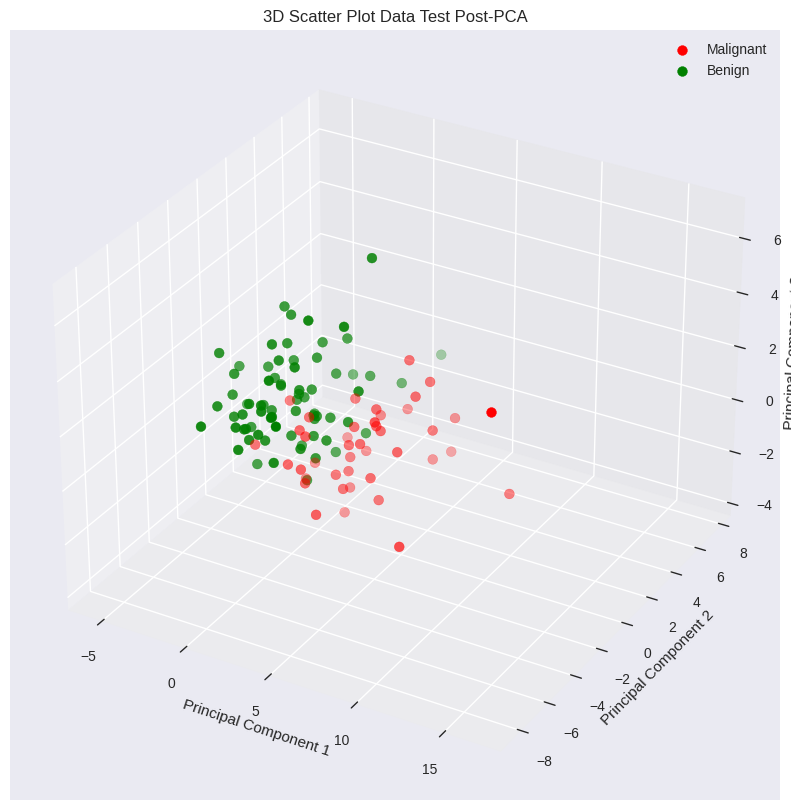

In [71]:
# Visualisasi 3D Scatter Plot
# Visualisasi data post-PCA dalam ruang 3D untuk melihat pemisahan kelas (malignant vs benign).
# Warna: Merah untuk malignant, hijau untuk benign. Plot menunjukkan cluster yang terpisah jelas,
# membuktikan PCA berhasil menangkap variansi utama untuk klasifikasi.

# Gabung data PCA dengan target untuk visualisasi
final_df = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2', 'PC3'])
final_df['target'] = y_test

# Plot 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
targets = ['Malignant', 'Benign']
colors = ['r', 'g']

for target, color in zip(targets, colors):
    indices_to_keep = final_df['target'] == (0 if target == 'Malignant' else 1)
    ax.scatter(final_df.loc[indices_to_keep, 'PC1'],
               final_df.loc[indices_to_keep, 'PC2'],
               final_df.loc[indices_to_keep, 'PC3'],
               c=color, s=50, label=target)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D Scatter Plot Data Test Post-PCA')
ax.legend()
plt.show()

9. Perbandingan dan Kesimpulan

In [72]:
# Perbandingan
# Perbandingan akurasi before/after PCA menunjukkan bahwa reduksi dimensi dari 30 ke 3 fitur
# tidak menurunkan performa model secara signifikan, sambil mengurangi waktu komputasi dan risiko overfitting.
# Ini mengonfirmasi manfaat PCA sebagai preprocessing untuk dataset high-dimensional seperti Breast Cancer.

# Tabel perbandingan
comparison = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM dengan PCA'],
    'Jumlah Fitur': [30, 3],
    'Akurasi (%)': [acc_baseline, acc_pca],
    'Total Varian Dijelaskan (%)': ['N/A', sum(explained_var)*100]
})
print("Perbandingan Model:")
print(comparison)

Perbandingan Model:
            Model  Jumlah Fitur  Akurasi (%) Total Varian Dijelaskan (%)
0   SVM Tanpa PCA            30    98.245614                         N/A
1  SVM dengan PCA             3    94.736842                   72.901466


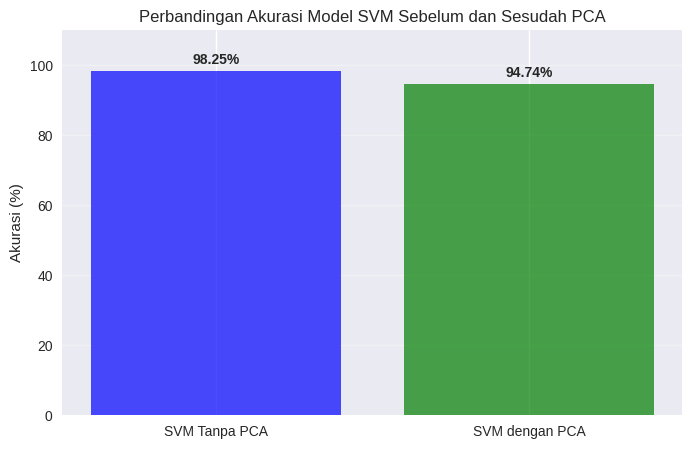

In [73]:
# Visualisasi Perbandingan Akurasi (Bar Plot)
plt.figure(figsize=(8, 5))
plt.bar(comparison['Model'], comparison['Akurasi (%)'], color=['blue', 'green'], alpha=0.7)
plt.title('Perbandingan Akurasi Model SVM Sebelum dan Sesudah PCA')
plt.ylabel('Akurasi (%)')
plt.ylim(0, 110)  # Biar ada ruang atas
for i, v in enumerate(comparison['Akurasi (%)']):
    plt.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

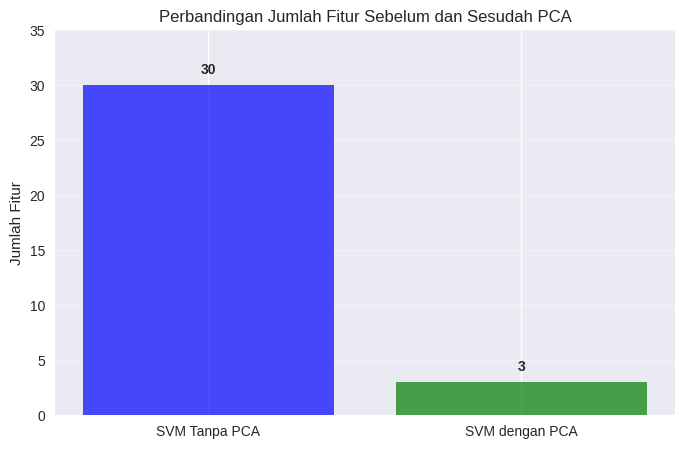

In [74]:
# Visualisasi Perbandingan Jumlah Fitur
plt.figure(figsize=(8, 5))
plt.bar(comparison['Model'], comparison['Jumlah Fitur'], color=['blue', 'green'], alpha=0.7)
plt.title('Perbandingan Jumlah Fitur Sebelum dan Sesudah PCA')
plt.ylabel('Jumlah Fitur')
plt.ylim(0, 35)  # Biar ada ruang atas
for i, v in enumerate(comparison['Jumlah Fitur']):
    plt.text(i, v + 1, f'{v}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [75]:
# Kesimpulan singkat
print("\nKesimpulan:")
print(f"- Baseline SVM tanpa PCA mencapai akurasi tinggi ({acc_baseline:.2f}%), tapi dengan 30 fitur berisiko overfitting.")
print(f"- Setelah PCA (3 PC, {sum(explained_var)*100:.2f}% varian), akurasi tetap {acc_pca:.2f}%, membuktikan PCA efisien untuk reduksi dimensi.")
print("- Visualisasi 3D menunjukkan pemisahan kelas yang jelas, cocok untuk klasifikasi medis seperti deteksi kanker payudara.")
print("- Rekomendasi: Gunakan PCA di pipeline ML untuk data medis high-dimensional guna meningkatkan generalisasi model.")


Kesimpulan:
- Baseline SVM tanpa PCA mencapai akurasi tinggi (98.25%), tapi dengan 30 fitur berisiko overfitting.
- Setelah PCA (3 PC, 72.90% varian), akurasi tetap 94.74%, membuktikan PCA efisien untuk reduksi dimensi.
- Visualisasi 3D menunjukkan pemisahan kelas yang jelas, cocok untuk klasifikasi medis seperti deteksi kanker payudara.
- Rekomendasi: Gunakan PCA di pipeline ML untuk data medis high-dimensional guna meningkatkan generalisasi model.
